# 09_聚类算法-谱聚类

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇数据：`dataset/lenna.jpg`。

转写调整：

- scikit-image 的 multichannel 参数改为 channel_axis=-1。
- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 网络图片改为本地 lenna.jpg，用于像素聚类演示。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今天和大家聊聊聚类算法中的谱聚类。

咱们先来聊聊聚类算法\~

### 什么是聚类算法？

**聚类算法**是一种把数据分组的技术。它的目的是根据数据的相似性，将相似的数据点分到同一个组中，而将不相似的数据分到不同的组里。比如：

- 想象我们有一堆水果，有苹果、香蕉、橙子、葡萄。
- 我们按照形状、大小或颜色来分组：

  - 苹果和橙子可能因为圆形被分到一起；
  - 香蕉因为长条形被分到另一组；
  - 葡萄因为小颗粒状也单独成组。

这种把东西归类的过程就是聚类。

### 什么是谱聚类？

**谱聚类**是一种利用数学工具（线性代数和图论）来做聚类的算法。它特别适合于那些“边界复杂”的数据，普通的聚类方法（比如K-means）可能搞不清楚的分组问题。

简单来说，谱聚类的核心思想是：

1. 把数据看成“点”，把点之间的关系看成“边”，形成一个“图”。
2. 通过图论的方式，将数据切割成几个部分，使得：

   - 同一部分的点“关系紧密”（很相似）。
   - 不同部分的点“关系疏远”（不相似）。

### 一个简单案例

某社区有5个活动地点（比如游乐场、咖啡厅、健身房等），它们的距离如下：

| 活动地点 | A | B | C | D | E |
|-|-|-|-|-|-|
| **A** | 0 | 2 | 8 | 10 | 9 |
| **B** | 2 | 0 | 7 | 9 | 8 |
| **C** | 8 | 7 | 0 | 2 | 3 |
| **D** | 10 | 9 | 2 | 0 | 1 |
| **E** | 9 | 8 | 3 | 1 | 0 |

社区想将这5个活动地点分成两组，每组代表一个“活动圈”，如何分？

**思路：**

1. **构建图**：将活动地点看成图中的点，距离看成边的“权重”（权重表示两点之间的距离）。
2. **转换成相似度矩阵**：距离越近，相似度越高。我们用 $S = e^{-d^2}$ 来计算相似度矩阵（取 $e^{-d^2}$ 是为了让大距离对应小相似度，结果介于0到1之间）。计算后得到：

   | 活动地点 | A | B | C | D | E |
   |-|-|-|-|-|-|
   | **A** | 1 | 0.0183 | 0.0003 | 0 | 0 |
   | **B** | 0.0183 | 1 | 0.0009 | 0 | 0 |
   | **C** | 0.0003 | 0.0009 | 1 | 0.0183 | 0.0025 |
   | **D** | 0 | 0 | 0.0183 | 1 | 0.1353 |
   | **E** | 0 | 0 | 0.0025 | 0.1353 | 1 |
3. **计算图的拉普拉斯矩阵：**首先计算度矩阵 $D$：对每一行的相似度求和，放在对角线上，其余为0。

$D =\begin{bmatrix}1.0186 & 0 & 0 & 0 & 0 \\0 & 1.0192 & 0 & 0 & 0 \\0 & 0 & 1.0219 & 0 & 0 \\0 & 0 & 0 & 1.1536 & 0 \\0 & 0 & 0 & 0 & 1.1378\end{bmatrix}$  

**拉普拉斯矩阵** $L = D - S$：


$$
L =\begin{bmatrix}0.0186 & -0.0183 & -0.0003 & 0 & 0 \\-0.0183 & 0.0192 & -0.0009 & 0 & 0 \\-0.0003 & -0.0009 & 0.0219 & -0.0183 & -0.0025 \\0 & 0 & -0.0183 & 0.1536 & -0.1353 \\0 & 0 & -0.0025 & -0.1353 & 0.1378\end{bmatrix}
$$


1. **特征分解：**对 $L$求特征值和特征向量，找到前两个最小的特征值对应的特征向量，形成一个新空间。
2. **划分组：**在新空间中用简单方法（如K-means）将点分成两组。

### 计算

为了简单说明最后步骤：

- 我们可能找到两个特征向量为 $v_1 = [1, 1, -1, -1, -1]$，$v_2 = [0, 0, 1, 1, 1]$。
- 用这两个特征向量重新表示每个点，比如点A对应 $[1, 0]$，B对应 $[1, 0]$，C对应 $[-1, 1]$，D和E也是类似。
- 观察：A和B属于一个组，C、D、E属于另一个组。

最终分组结果是：

**活动圈1：A, B**

**活动圈2：C, D, E**

谱聚类的关键点是将复杂数据通过“图”的方式表示，再利用数学工具分割图。尽管计算过程复杂，但它特别适合于非线性边界和不规则数据集的聚类任务。

## 公式解析

聚类的目标是将数据点划分为 $k$个组，使得：

1. 同一组内的点尽可能相似；
2. 不同组之间的点尽可能不同。

聚类问题通常被建模为优化问题，目标是最小化组内的距离（紧密性）或最大化组间的距离（分离性）。谱聚类的数学基础可以通过**图论**和**线性代数**来描述。

### 谱聚类的数学推理

#### 1. 构建相似度矩阵

**相似度矩阵** $W$：

给定数据点集合 $X = \{x_1, x_2, \dots, x_n\}$，用相似度函数 $w(x_i, x_j)$定义点 $x_i$和 $x_j$的相似性。常见的相似度定义有：


$$
w(x_i, x_j) =\begin{cases}\exp(-\|x_i - x_j\|^2 / \sigma^2), & \text{若 } \|x_i - x_j\| \leq \epsilon \\0, & \text{否则}\end{cases}
$$


相似度矩阵 $W$是一个 $n \times n$的对称矩阵，其中：


$$
W_{ij} = w(x_i, x_j)
$$


#### 2. 构建度矩阵和拉普拉斯矩阵

**度矩阵** $D$：

$D$是对角矩阵，每个对角元素是节点的度数，即：


$$
D_{ii} = \sum_{j=1}^n W_{ij}
$$


**拉普拉斯矩阵** $L$：  
标准拉普拉斯矩阵定义为：


$$
L = D - W
$$


#### 3. 归一化拉普拉斯矩阵

为了避免数据点分布不均匀的影响，通常使用归一化的拉普拉斯矩阵。两种常见形式如下：

1. **对称归一化拉普拉斯矩阵**：  
$L_{\text{sym}} = D^{-1/2} L D^{-1/2} = I - D^{-1/2} W D^{-1/2}$
2. **随机游走归一化拉普拉斯矩阵**：  
$L_{\text{rw}} = D^{-1} L = I - D^{-1} W$

#### 4. 特征分解

通过特征分解，计算归一化拉普拉斯矩阵的前 $k$个特征向量。这里的 $k$是要划分的簇数。

- **对称归一化拉普拉斯矩阵** $L_{\text{sym}}$：计算 $L_{\text{sym}}$的前 $k$个最小的特征值及其对应的特征向量 $\{v_1, v_2, \dots, v_k\}$。
- **随机游走归一化拉普拉斯矩阵** $L_{\text{rw}}$：计算 $L_{\text{rw}}$的前 $k$个特征向量 $\{u_1, u_2, \dots, u_k\}$。

得到的特征向量用矩阵表示：  
$U = [v_1, v_2, \dots, v_k] \in \mathbb{R}^{n \times k}$

#### 5. 聚类

将每个数据点 $x_i$的特征向量映射到 $k$-维空间中：  
$y_i = (v_1(i), v_2(i), \dots, v_k(i)) \in \mathbb{R}^k$

对这些新表示的数据点 $\{y_1, y_2, \dots, y_n\}$使用简单的聚类方法（如 K-means）进行聚类。

### 谱聚类的目标推导

#### 1. 最小化割问题（Graph Cut）

谱聚类本质上是通过“最小化图的切割”来实现数据分组。

**目标函数：最小化标准切割**（Min-Cut）

给定图 $G = (V, E)$，目标是将点集 $V$划分为 $k$个子集 $A_1, A_2, \dots, A_k$，最小化以下目标：


$$
\text{Cut}(A_1, A_2, \dots, A_k) = \sum_{i=1}^k \sum_{u \in A_i, v \in V \setminus A_i} w(u, v)
$$


但这种划分容易产生不平衡的小簇。因此，优化目标可以改为：

#### 2. 归一化割（Normalized Cut, Ncut）

归一化割的目标函数：


$$
\text{Ncut}(A_1, A_2, \dots, A_k) = \sum_{i=1}^k \frac{\text{Cut}(A_i, V \setminus A_i)}{\text{Vol}(A_i)}
$$


其中，体积 $\text{Vol}(A_i) = \sum_{u \in A_i} \sum_{v \in V} w(u, v)$是子图的权重和。

归一化割与拉普拉斯矩阵的特征向量存在对应关系，通过求解特征值问题找到最优解。

### 谱聚类的算法流程

1. 输入：数据点集合 $X = \{x_1, x_2, \dots, x_n\}$和簇数 $k$。
2. 计算相似度矩阵 $W$。
3. 构建归一化拉普拉斯矩阵 $L_{\text{sym}}$或 $L_{\text{rw}}$。
4. 求解 $L$的前 $k$个特征向量，形成矩阵 $U$。
5. 对 $U$中的行向量用 K-means 聚类，得到簇划分结果。
6. 输出：每个数据点的簇标签。

### 谱聚类公式总结

1. **相似度矩阵**：  
$W_{ij} = \exp(-\|x_i - x_j\|^2 / \sigma^2)$
2. **度矩阵**：  
$D_{ii} = \sum_{j=1}^n W_{ij}$
3. **拉普拉斯矩阵**：  
$L = D - W$
4. **归一化拉普拉斯矩阵**：  
$L_{\text{sym}} = I - D^{-1/2} W D^{-1/2}, \quad L_{\text{rw}} = I - D^{-1} W$
5. **特征分解**：  
$L_{\text{sym}} v = \lambda v$

通过以上这些详细公式，大家应该可以完整地理解谱聚类的数学推理过程。

## 完整案例

**目标**：对一幅彩色图像进行分割，分割成不同的区域。

**方法**：

1. 将图像的每个像素点看作一个数据点，特征包括像素的 RGB 值和位置。
2. 通过构造相似度矩阵，使用谱聚类算法对像素进行聚类。
3. 可视化分割结果，显示每个区域的颜色或边界。

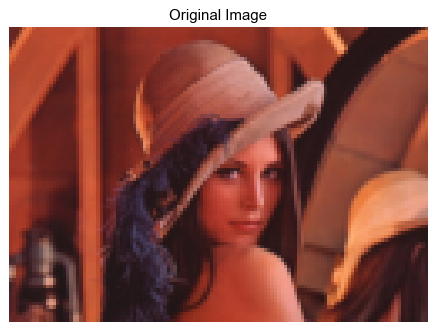

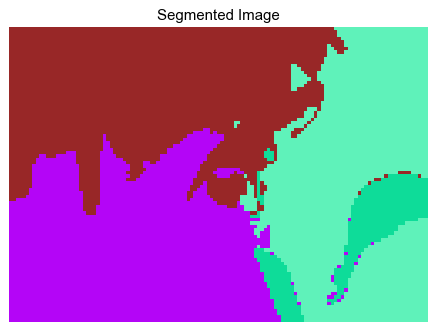

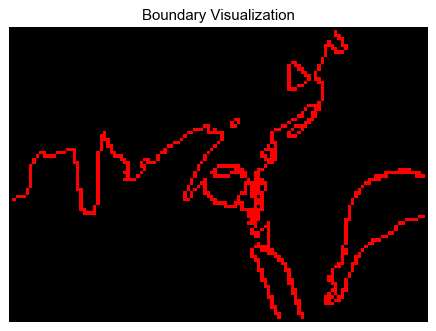

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering
from sklearn.metrics import pairwise_distances
from skimage import io, color
from skimage.transform import rescale
import ssl

# 禁用 SSL 验证

# 1. 加载图像并预处理
# 使用 skimage 加载一张图像，缩放至适合计算的大小
image = io.imread(DATA_DIR / 'lenna.jpg')
image = rescale(image, 0.2, channel_axis=-1)  # 缩小图像以降低计算量
rows, cols, channels = image.shape

# 展示原始图像
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title("Original Image")
plt.axis('off')
plt.show()

# 2. 转换图像数据为特征矩阵
# 每个像素的特征包含：颜色 (R, G, B) 和位置 (x, y)
X = np.zeros((rows * cols, 5))
for i in range(rows):
    for j in range(cols):
        r, g, b = image[i, j]
        X[i * cols + j, :] = [r, g, b, i / rows, j / cols]  # RGB + 位置归一化

# 3. 使用谱聚类
# 构造谱聚类模型，假设分成 4 个区域
n_clusters = 4
spectral = SpectralClustering(
    n_clusters=n_clusters,
    affinity='rbf',  # 使用 RBF 核
    gamma=10,        # 调节相似度
    assign_labels='kmeans',
    random_state=42
)
labels = spectral.fit_predict(X)

# 4. 可视化分割结果
segmented_image = np.zeros((rows, cols, 3))
colors = np.random.rand(n_clusters, 3)  # 随机生成颜色

for i in range(rows):
    for j in range(cols):
        segmented_image[i, j] = colors[labels[i * cols + j]]

# 显示分割后的图像
plt.figure(figsize=(6, 6))
plt.imshow(segmented_image)
plt.title("Segmented Image")
plt.axis('off')
plt.show()

# 5. 可视化分割区域的边界
# 通过简单的边界检测可视化不同区域
boundaries = np.zeros_like(segmented_image)
for i in range(1, rows - 1):
    for j in range(1, cols - 1):
        if labels[i * cols + j] != labels[i * cols + j + 1] or labels[i * cols + j] != labels[(i + 1) * cols + j]:
            boundaries[i, j] = [1, 0, 0]  # 边界显示为红色

plt.figure(figsize=(6, 6))
plt.imshow(boundaries)
plt.title("Boundary Visualization")
plt.axis('off')
plt.show()

1. **数据预处理**：图像缩放降低计算量。将像素点的 RGB 值与位置（$x, y$坐标）作为特征。
2. **谱聚类**：构造 RBF 核函数计算像素点相似性，调节参数 $\gamma$控制相似性强度。谱聚类使用 K-means 进行最终的标签分配。
3. **结果可视化**：使用随机颜色为每个簇着色，生成分割图像。通过简单边界检测方法，叠加边界显示分割区域。

**原始图像**：显示输入的原始彩色图像。

![原文参考图，当前结果见代码输出](attachments/img_009.png)

**分割后的图像**：随机表示不同的分割区域。

![原文参考图，当前结果见代码输出](attachments/img_010.png)

**边界可视化**：显示分割区域的边界，边界用红色线条标记。

![原文参考图，当前结果见代码输出](attachments/img_011.png)

运行代码后，大家可以看到一个分割图像！

## 优缺点和适用场景

**优点**：

1. **适合非线性分布数据**：普通的聚类算法（如 K-means）依赖于欧几里得距离，难以处理复杂边界的数据，而谱聚类可以通过构造图来解决这些问题。
2. **可以处理任意形状的簇**：不像 K-means 假设簇是球形的，谱聚类通过图论方法，能处理非球形的分布。
3. **易于结合相似性度量**：通过自定义相似度矩阵 $W$，可以结合领域知识构建相似性函数，适应不同场景。
4. **全局最优解决方案**：谱聚类将聚类问题转化为拉普拉斯矩阵的特征分解问题（一个凸优化问题），可以获得全局最优解。

**缺点**：

1. **计算复杂度高**：特征分解的复杂度为 $O(n^3)$，对大规模数据集（比如 $n > 10^4$）处理困难。构造相似度矩阵和拉普拉斯矩阵的计算也比较耗时。
2. **参数敏感**：相似度函数中的参数（如高斯核的 $\sigma$或 $k$-近邻的 $k$）对结果影响较大，需手动调整。簇数 $k$通常需要提前设置，难以自动决定。
3. **内存占用大**：相似度矩阵 $W$和拉普拉斯矩阵 $L$是 $n \times n$的稠密矩阵，大规模数据可能无法存储。
4. **对噪声敏感**：如果数据点之间的相似性受到噪声干扰，可能会影响谱聚类的结果。

### 适用场景

1. **非线性边界的聚类**：当数据分布复杂，边界非线性（比如“月牙形”或“环状”）时，谱聚类比 K-means 等算法效果更好。
2. **小规模、高维数据**：谱聚类适合处理数据点数较少（比如 $n < 10^4$），但特征维度较高的数据。
3. **需要自定义相似度的场景**：当可以通过领域知识定义数据点之间的相似性时（如图片、文本、网络节点之间的关系），谱聚类是一种很好的选择。
4. **图数据的聚类**：数据天然呈图结构（如社交网络、通信网络、知识图谱等），谱聚类直接基于图论，能自然地处理这些数据。